# 02 — Baseline "Classic" Model (TF-IDF + Linear Classifiers)
**SEA 820 Final Project: Detecting AI-Generated Text**

Team: Aditi & Victoria

This notebook builds the **baseline** that our fine-tuned Transformer (notebook `03`) must beat.
We follow the data decisions established in `01_eda.ipynb`:

- Class imbalance (~63% human / ~37% AI) → we report **precision, recall, and F1**, not just accuracy, and use a **stratified** split.
- **0** exact duplicates; **36** junk texts under 20 words (all AI) → removed as noise.

We train and **compare three classic classifiers** on TF-IDF features
(Logistic Regression, Multinomial Naive Bayes, Linear SVM) and inspect the most
informative features to understand what the linear model is learning.

## 0. Setup — download the dataset
Same Kaggle download used in `01_eda.ipynb`. In Colab, upload your `kaggle.json` when prompted. If you already have `AI_Human.csv` locally, skip this cell.

## Load data from Google Drive

If you prefer to load the dataset from your Google Drive, make sure the `AI_Human(1).csv` file is in your Drive and run the following cells.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42  # single seed reused everywhere for reproducibility


## 1. Load data

In [3]:
df = pd.read_csv('/content/drive/MyDrive/AI_Human (1).csv', usecols=["text", "generated"])
df["generated"] = df["generated"].astype("int8")   # 0 = human, 1 = AI
print("Raw shape:", df.shape)
print(df["generated"].value_counts())
df.head(3)

Raw shape: (487235, 2)
generated
0    305797
1    181438
Name: count, dtype: int64


,text,generated
0,Cars. Cars have been around since they became ...,0
1,Transportation is a large necessity in most co...,0
2,"""America's love affair with it's vehicles seem...",0


## 2. Apply the EDA quality filters
From `01_eda.ipynb`: remove exact duplicates (found 0) and texts shorter than
20 words (found 36, all in the AI class — template placeholders and leaked
prompts). Leaving them in would teach the model a spurious *"broken text = AI"*
shortcut.

In [4]:
n_before = len(df)
df = df.drop_duplicates(subset="text")
n_dupes = n_before - len(df)

word_len = df["text"].str.count(r"\s+") + 1          # cheap word count (no split)
short_mask = word_len < 20
n_short = int(short_mask.sum())
df = df[~short_mask].reset_index(drop=True)

print(f"Removed {n_dupes} duplicates and {n_short} short (<20 word) texts.")
print(f"Final dataset: {len(df):,} rows")
print(df["generated"].value_counts(normalize=True).round(3).to_dict())


Removed 0 duplicates and 36 short (<20 word) texts.
Final dataset: 487,199 rows
{0: 0.628, 1: 0.372}


## 3. Stratified train/test split
An 80/20 split with `stratify` preserves the ~63/37 class ratio in both partitions.
**We reuse this exact split (same seed, same filters) in notebook `03`** so the
baseline and the Transformer are compared on identical data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"], df["generated"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["generated"])

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print("Train class balance:", y_train.value_counts(normalize=True).round(3).to_dict())
print("Test  class balance:", y_test.value_counts(normalize=True).round(3).to_dict())


Train: 389,759 | Test: 97,440
Train class balance: {0: 0.628, 1: 0.372}
Test  class balance: {0: 0.628, 1: 0.372}


## 4. TF-IDF features
**Feature-engineering choices (beyond plain TF-IDF):**
- `ngram_range=(1, 2)` — unigrams **and** bigrams, so short stylistic phrases
  (a known signal of AI "essay-speak") are captured.
- `sublinear_tf=True` — log-scales term frequency so very repetitive documents
  don't dominate.
- `min_df=5` + `max_features=50000` — drop ultra-rare terms and cap the vocabulary
  (keeps memory reasonable and reduces overfitting to topic-specific words).
- `strip_accents='unicode'` — normalises accented characters.

> **Low-RAM note:** if you hit a memory error (e.g. a small local machine),
> set `ngram_range=(1, 1)` and `max_features=30000`. This is a lighter but still
> valid baseline; on Colab the (1,2) configuration fits comfortably.

In [6]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=5,
    max_features=50000,
    sublinear_tf=True,
    strip_accents="unicode",
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print("TF-IDF train matrix:", X_train_tfidf.shape)
print("Vocabulary size:", len(tfidf.vocabulary_))


TF-IDF train matrix: (389759, 50000)
Vocabulary size: 50000


## 5. Train and compare three classic classifiers
We evaluate:
1. **Logistic Regression** — strong, interpretable linear baseline.
2. **Multinomial Naive Bayes** — classic fast text baseline.
3. **Linear SVM** — often the strongest linear model on TF-IDF.

`class_weight='balanced'` is used for the discriminative models to counteract the
class imbalance. We record every metric the rubric asks for.

In [7]:
def evaluate_model(name, model, results):
    """Fit a model, print a full report, and store metrics in `results`."""
    model.fit(X_train_tfidf, y_train)
    pred = model.predict(X_test_tfidf)

    results[name] = {
        "Accuracy":        accuracy_score(y_test, pred),
        "Precision (AI)":  precision_score(y_test, pred, pos_label=1),
        "Recall (AI)":     recall_score(y_test, pred, pos_label=1),
        "F1 (AI)":         f1_score(y_test, pred, pos_label=1),
        "F1 (macro)":      f1_score(y_test, pred, average="macro"),
        "F1 (weighted)":   f1_score(y_test, pred, average="weighted"),
    }
    print(f"\n===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Human", "AI"], digits=4))
    return model, pred

results = {}
lr_model, lr_pred = evaluate_model(
    "Logistic Regression",
    LogisticRegression(max_iter=1000, C=1.0, class_weight="balanced"),
    results)

nb_model, nb_pred = evaluate_model(
    "Multinomial NB",
    MultinomialNB(),
    results)

svm_model, svm_pred = evaluate_model(
    "Linear SVM",
    LinearSVC(C=1.0, class_weight="balanced"),
    results)



===== Logistic Regression =====
              precision    recall  f1-score   support

       Human     0.9962    0.9979    0.9970     61159
          AI     0.9965    0.9935    0.9950     36281

    accuracy                         0.9963     97440
   macro avg     0.9963    0.9957    0.9960     97440
weighted avg     0.9963    0.9963    0.9963     97440


===== Multinomial NB =====
              precision    recall  f1-score   support

       Human     0.9687    0.9884    0.9784     61159
          AI     0.9798    0.9461    0.9626     36281

    accuracy                         0.9727     97440
   macro avg     0.9742    0.9673    0.9705     97440
weighted avg     0.9728    0.9727    0.9726     97440


===== Linear SVM =====
              precision    recall  f1-score   support

       Human     0.9998    0.9997    0.9998     61159
          AI     0.9995    0.9996    0.9996     36281

    accuracy                         0.9997     97440
   macro avg     0.9997    0.9997    0.9997

## 6. Results comparison

In [8]:
results_df = pd.DataFrame(results).T.round(4)
results_df = results_df.sort_values("F1 (macro)", ascending=False)
print("Baseline model comparison (sorted by macro-F1):")
results_df


Baseline model comparison (sorted by macro-F1):


,Accuracy,Precision (AI),Recall (AI),F1 (AI),F1 (macro),F1 (weighted)
Linear SVM,0.9997,0.9995,0.9996,0.9996,0.9997,0.9997
Logistic Regression,0.9963,0.9965,0.9935,0.9950,0.9960,0.9963
Multinomial NB,0.9727,0.9798,0.9461,0.9626,0.9705,0.9726


The confusion matrix for the best baseline model shows *where* it errs — useful input for the error analysis in the analysis phase.

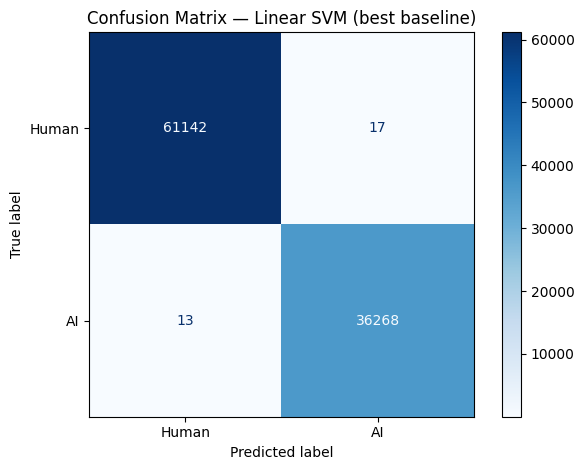

In [9]:
best_name = results_df.index[0]
best_pred = {"Logistic Regression": lr_pred,
             "Multinomial NB": nb_pred,
             "Linear SVM": svm_pred}[best_name]

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — {best_name} (best baseline)")
plt.tight_layout()
plt.savefig("baseline_confusion_matrix.png", dpi=150)
plt.show()


## 7. What is the linear model learning?
The Logistic Regression coefficients are directly interpretable: the most positive
weights push toward **AI**, the most negative toward **human**. Compare these with
the vocabulary findings from `01_eda.ipynb` — watch for **dataset artifacts**
(e.g. anonymisation tokens like `teacher_name` that appear only in human essays)
rather than genuine style signals.

In [10]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_ai    = feature_names[np.argsort(coefs)[-25:]][::-1]
top_human = feature_names[np.argsort(coefs)[:25]]

print("Top features pushing toward AI:\n", list(top_ai))
print("\nTop features pushing toward HUMAN:\n", list(top_human))


Top features pushing toward AI:
 ['it like', 'important', 'essay', 'additionally', 'super', 're', 'important to', 'it not', 'potential', 'hey', 'conclusion', 'in conclusion', 'it important', 'cool', 'provide', 'and stuff', 'however', 'believe that', 'significant', 'this essay', 'and', 'lead to', 'think it', 'totally', 'essential']

Top features pushing toward HUMAN:
 ['because', 'very', 'would', 'the students', 'many', 'although', 'you', 'people', 'will', 'paragraph', 'driving', 'percent', 'because of', 'car', 'said', 'being', 'going', 'all', 'that is', 'then', 'go', 'venus', 'for the', 'humans', 'nasa']


## 8. Save the baseline & summary
We persist the metrics (and the best model) so notebook `03` can load them for a
side-by-side comparison, and so the numbers can be pasted into the report.

In [11]:
import json, joblib

summary = {
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "tfidf_features": int(X_train_tfidf.shape[1]),
    "best_model": best_name,
    "metrics": {k: {m: round(float(v), 4) for m, v in d.items()}
                for k, d in results.items()},
    "top_ai_features": list(map(str, top_ai)),
    "top_human_features": list(map(str, top_human)),
}

# CHANGED: save to Drive instead of local Colab storage, so it survives
# after the session ends and 03 can find it later
with open("/content/drive/MyDrive/baseline_results.json", "w") as f:
    json.dump(summary, f, indent=2)

# Persist the best pipeline for reuse / inference
joblib.dump({"vectorizer": tfidf, "model": lr_model}, "baseline_lr_tfidf.joblib")

print("Saved baseline_results.json to Google Drive and baseline_lr_tfidf.joblib locally")
print(f"\nBASELINE SCORE TO BEAT — {best_name}: "
      f"macro-F1 = {results[best_name]['F1 (macro)']:.4f}, "
      f"accuracy = {results[best_name]['Accuracy']:.4f}")

Saved baseline_results.json to Google Drive and baseline_lr_tfidf.joblib locally

BASELINE SCORE TO BEAT — Linear SVM: macro-F1 = 0.9997, accuracy = 0.9997


### Summary
- Built a stratified, imbalance-aware baseline on TF-IDF (1–2 gram) features.
- Compared **three** classic classifiers and reported accuracy, precision, recall,
  and F1 (per-class and averaged).
- Inspected the most informative features, flagging dataset artifacts for the
  error analysis.

**Next:** `03_transformer_distilbert.ipynb` — fine-tune DistilBERT on the *same*
split and beat this baseline.